**powershell 에서 uv add langraph로 모듈 설치**

In [2]:
from langchain_ollama import ChatOllama
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage

model = ChatOllama(model="gemma4:e2b", base_url="http://127.0.0.1:11434") 
model.invoke('안녕하세요!')

AIMessage(content='안녕하세요! 😊 만나서 반갑습니다.\n\n무엇을 도와드릴까요?', additional_kwargs={}, response_metadata={'model': 'gemma4:e2b', 'created_at': '2026-10-04T09:48:17.6960187Z', 'done': True, 'done_reason': 'stop', 'total_duration': 28150355300, 'load_duration': 25265756900, 'prompt_eval_count': 18, 'prompt_eval_duration': 125665000, 'eval_count': 232, 'eval_duration': 2755438000, 'logprobs': None, 'model_name': 'gemma4:e2b', 'model_provider': 'ollama'}, id='lc_run--01a10650-03a5-78b0-b833-4255369c89a9-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 18, 'output_tokens': 232, 'total_tokens': 250})

In [3]:
from typing import Annotated # annotated는 타입 힌트를 사용할 때 사용하는 함수
from typing_extensions import TypedDict # TypedDict는 딕셔너리 타입을 정의할 때 사용하는 클래스

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

class State(TypedDict):	#①
    """
    State 클래스는 TypedDict를 상속받습니다.

    속성:
        messages (Annotated[list[str], add_messages]): 메시지들은 "list" 타입을 가집니다.   #②
       'add_messages' 함수는 이 상태 키가 어떻게 업데이트되어야 하는지를 정의합니다.  #③
        (이 경우, 메시지를 덮어쓰는 대신 리스트에 추가합니다)
    """
    messages: Annotated[list[str], add_messages]	#②

# StateGraph 클래스를 사용하여 State 타입의 그래프를 생성합니다.
graph_builder = StateGraph(State) #④

In [4]:
def generate(state: State):	#①
    """
    주어진 상태를 기반으로 챗봇의 응답 메시지를 생성합니다.

    매개변수:
    state (State): 현재 대화 상태를 나타내는 객체로, 이전 메시지들이 포함되어 있습니다.
		
    반환값:
    dict: 모델이 생성한 응답 메시지를 포함하는 딕셔너리. 
          형식은 {"messages": [응답 메시지]}입니다.
    """ 
    return {"messages": [model.invoke(state["messages"])]}	#②

graph_builder.add_node("generate", generate)	#③

In [5]:
graph_builder.add_edge(START, "generate")
graph_builder.add_edge("generate", END)    

graph = graph_builder.compile()

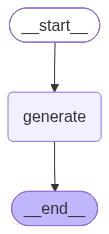

In [6]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception: 
    pass

In [7]:
response = graph.invoke({"messages": ["안녕하세요! 저는 정성락입니다"]})

print(type(response))
response

<class 'dict'>


{'messages': [HumanMessage(content='안녕하세요! 저는 정성락입니다', additional_kwargs={}, response_metadata={}, id='57cc3aa3-5fac-415a-b6a0-5527ad7bba59'),
  AIMessage(content='안녕하세요, 정성락님! 만나 뵙게 되어 반갑습니다. 😊\n\n저는 사용자와 대화하고 정보를 제공하는 인공지능입니다.\n\n혹시 오늘 어떤 이야기를 나누고 싶으신가요? 궁금한 점이나 도움이 필요하시면 언제든지 말씀해주세요!', additional_kwargs={}, response_metadata={'model': 'gemma4:e2b', 'created_at': '2026-10-04T09:48:21.0205541Z', 'done': True, 'done_reason': 'stop', 'total_duration': 1000552600, 'load_duration': 7808900, 'prompt_eval_count': 23, 'prompt_eval_duration': 119176000, 'eval_count': 58, 'eval_duration': 868064000, 'logprobs': None, 'model_name': 'gemma4:e2b', 'model_provider': 'ollama'}, id='lc_run--01a10650-7ab2-79f0-8fb3-636f599f4a88-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 23, 'output_tokens': 58, 'total_tokens': 81})]}

In [8]:
response["messages"].append("제 이름을 아시나요?")
graph.invoke(response)

{'messages': [HumanMessage(content='안녕하세요! 저는 정성락입니다', additional_kwargs={}, response_metadata={}, id='57cc3aa3-5fac-415a-b6a0-5527ad7bba59'),
  AIMessage(content='안녕하세요, 정성락님! 만나 뵙게 되어 반갑습니다. 😊\n\n저는 사용자와 대화하고 정보를 제공하는 인공지능입니다.\n\n혹시 오늘 어떤 이야기를 나누고 싶으신가요? 궁금한 점이나 도움이 필요하시면 언제든지 말씀해주세요!', additional_kwargs={}, response_metadata={'model': 'gemma4:e2b', 'created_at': '2026-10-04T09:48:21.0205541Z', 'done': True, 'done_reason': 'stop', 'total_duration': 1000552600, 'load_duration': 7808900, 'prompt_eval_count': 23, 'prompt_eval_duration': 119176000, 'eval_count': 58, 'eval_duration': 868064000, 'logprobs': None, 'model_name': 'gemma4:e2b', 'model_provider': 'ollama'}, id='lc_run--01a10650-7ab2-79f0-8fb3-636f599f4a88-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 23, 'output_tokens': 58, 'total_tokens': 81}),
  HumanMessage(content='제 이름을 아시나요?', additional_kwargs={}, response_metadata={}, id='2da4f140-7b0c-48f0-b272-30cd6cc73d58'),
  AIMessage(content='네, 알고 있습니

In [9]:
inputs = {"messages": [("human", "한국과 일본의 관계에 대해 자세히 알려줘")]}
for chunk, _ in graph.stream(inputs, stream_mode="messages"):
    print(chunk.content, end="")

한국과 일본의 관계는 역사적 배경, 지리적 근접성, 그리고 현재의 경제적 상호의존성으로 인해 매우 복잡하고 다층적입니다. 이는 때로는 긴밀한 협력과 깊은 이해를 바탕으로 하지만, 때로는 역사적 인식 차이와 지정학적 문제로 인해 긴장감이 발생하는 양면성을 동시에 지니고 있습니다.

다음은 한일 관계의 주요 측면들을 자세히 설명해 드립니다.

---

## 1. 역사적 배경 및 인식 차이

한일 관계를 이해하는 데 있어 가장 중요한 부분은 역사 인식의 차이입니다.

*   **과거의 갈등:** 일제강점기라는 역사적 사건은 양국 관계의 근본적인 긴장 요소입니다. 한국은 일본 제국주의의 식민 지배를 경험했으며, 이로 인해 역사적 정의와 관련된 민감한 감정이 존재합니다.
*   **사과와 화해 노력:** 1965년 한일 기본조약 등을 통해 일부 사과와 화해의 노력이 있었으나, 여전히 과거사 문제에 대한 해석과 기억은 양국 간에 큰 차이를 보입니다.
*   **역사 인식의 충돌:** 일본의 역사 교육과 한국의 역사 교육에서 식민 지배와 관련된 사건들에 대한 해석이 상이하기 때문에, 이 지점은 외교 및 대중 관계에서 지속적인 민감한 주제로 다루어집니다.

## 2. 경제적 관계: 깊은 상호의존성

역사적 갈등에도 불구하고, 1965년 이후 한일 양국은 세계적으로 가장 긴밀한 경제 관계 중 하나를 형성하고 있습니다.

*   **주요 무역국:** 양국은 막대한 규모의 상품과 서비스 교류를 하며 깊은 경제적 상호의존성을 가지고 있습니다. 일본은 한국의 주요 수출 대상국 중 하나이며, 한국은 일본 제품에 대한 높은 수요를 보입니다.
*   **첨단 기술 및 공급망:** 특히 반도체, 자동차, 전자 부품 등 첨단 산업 분야에서 양국은 긴밀한 공급망을 공유하며 협력하고 있습니다.
*   **투자:** 양국 간의 직접 투자(FDI)와 금융 흐름도 활발하게 이루어지고 있습니다.

## 3. 안보 및 외교 관계

안보 문제는 한일 관계에서 가장 민감하고 복잡한 영역입니다.

*   **